In [1]:
!pip -q install pandas numpy matplotlib seaborn plotly reportlab kaleido

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 2.3 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path
from collections import Counter
from IPython.display import display, HTML

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
url = "https://raw.githubusercontent.com/12345k/IPL-Dataset/master/IPL/data.csv"

df = pd.read_csv(url)

print("Dataset downloaded successfully.")
print("Shape:", df.shape)

Dataset downloaded successfully.
Shape: (577, 18)


In [4]:
display(df.head())

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2008,Bangalore,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Kolkata Knight Riders,140,0,BB McCullum,M Chinnaswamy Stadium,Asad Rauf,RE Koertzen,NaN
1,2,2008,Chandigarh,2008-04-19,Chennai Super Kings,Kings XI Punjab,Chennai Super Kings,bat,normal,0,Chennai Super Kings,33,0,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",MR Benson,SL Shastri,NaN
2,3,2008,Delhi,2008-04-19,Rajasthan Royals,Delhi Daredevils,Rajasthan Royals,bat,normal,0,Delhi Daredevils,0,9,MF Maharoof,Feroz Shah Kotla,Aleem Dar,GA Pratapkumar,NaN
3,4,2008,Mumbai,2008-04-20,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,normal,0,Royal Challengers Bangalore,0,5,MV Boucher,Wankhede Stadium,SJ Davis,DJ Harper,NaN
4,5,2008,Kolkata,2008-04-20,Deccan Chargers,Kolkata Knight Riders,Deccan Chargers,bat,normal,0,Kolkata Knight Riders,0,5,DJ Hussey,Eden Gardens,BF Bowden,K Hariharan,NaN


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

Number of rows: 577
Number of columns: 18

Columns:
['id', 'season', 'city', 'date', 'team1', 'team2', 'toss_winner', 'toss_decision', 'result', 'dl_applied', 'winner', 'win_by_runs', 'win_by_wickets', 'player_of_match', 'venue', 'umpire1', 'umpire2', 'umpire3']

Data types:


,0
id,int64
season,int64
city,object
date,object
team1,object
team2,object
toss_winner,object
toss_decision,object
result,object
dl_applied,int64


In [6]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,577.0,NaN,NaN,NaN,289.0,166.709828,1.0,145.0,289.0,433.0,577.0
season,577.0,NaN,NaN,NaN,2012.029463,2.486247,2008.0,2010.0,2012.0,2014.0,2016.0
city,570,30,Mumbai,77,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,577,407,2016-05-22,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
team1,577,13,Chennai Super Kings,77,NaN,NaN,NaN,NaN,NaN,NaN,NaN
team2,577,13,Royal Challengers Bangalore,77,NaN,NaN,NaN,NaN,NaN,NaN,NaN
toss_winner,577,13,Mumbai Indians,74,NaN,NaN,NaN,NaN,NaN,NaN,NaN
toss_decision,577,2,field,315,NaN,NaN,NaN,NaN,NaN,NaN,NaN
result,577,3,normal,568,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dl_applied,577.0,NaN,NaN,NaN,0.025997,0.159263,0.0,0.0,0.0,0.0,1.0


In [7]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Column": missing.index,
    "Missing Values": missing.values,
    "Missing Percentage": (missing.values / len(df)) * 100
})

missing_df = missing_df.sort_values(
    by="Missing Values",
    ascending=False
)

display(missing_df)

,Column,Missing Values,Missing Percentage
17,umpire3,577,100.000000
2,city,7,1.213172
10,winner,3,0.519931
13,player_of_match,3,0.519931
1,season,0,0.000000
0,id,0,0.000000
6,toss_winner,0,0.000000
3,date,0,0.000000
4,team1,0,0.000000
5,team2,0,0.000000


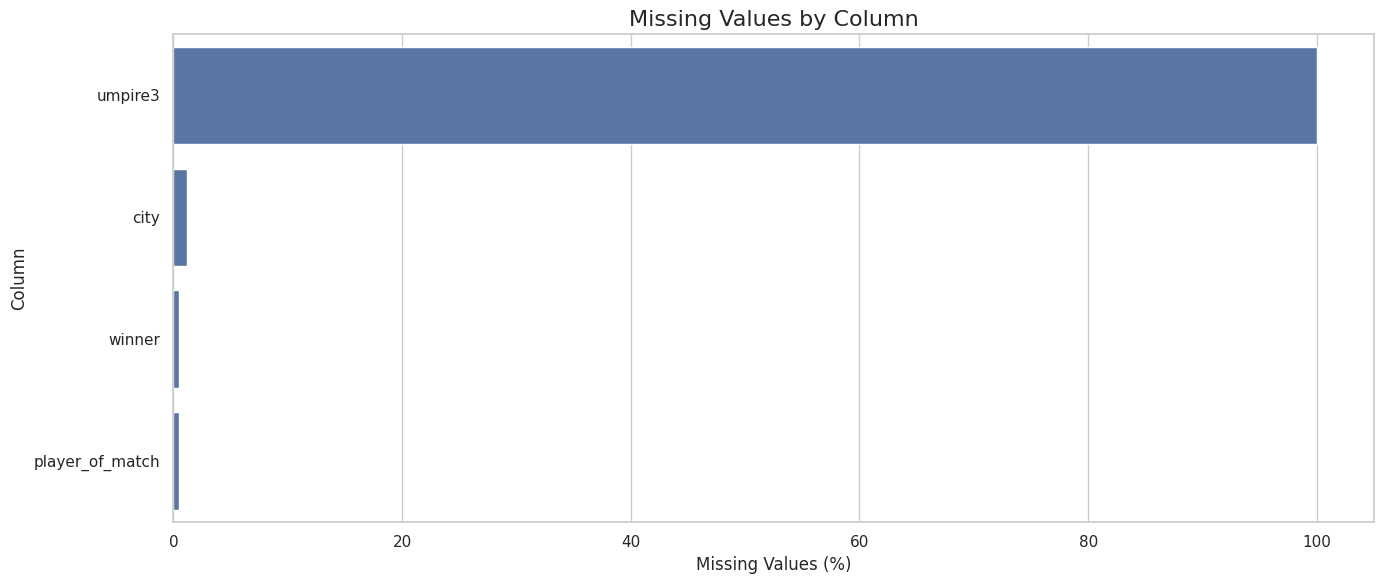

In [8]:
plt.figure(figsize=(14, 6))

missing_percentage = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

missing_percentage = missing_percentage[missing_percentage > 0]

sns.barplot(
    x=missing_percentage.values,
    y=missing_percentage.index
)

plt.title("Missing Values by Column")
plt.xlabel("Missing Values (%)")
plt.ylabel("Column")
plt.tight_layout()
plt.show()

In [9]:
duplicate_count = df.duplicated().sum()

print("Duplicate records:", duplicate_count)

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Duplicate records: 0
Shape after removing duplicates: (577, 18)


In [10]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(df.columns.tolist())

['id', 'season', 'city', 'date', 'team1', 'team2', 'toss_winner', 'toss_decision', 'result', 'dl_applied', 'winner', 'win_by_runs', 'win_by_wickets', 'player_of_match', 'venue', 'umpire1', 'umpire2', 'umpire3']


In [12]:
# Convert blank strings to NaN
df = df.replace(r'^\s*$', np.nan, regex=True)

# Important categorical columns
categorical_columns = [
    "city",
    "winner",
    "player_of_match",
    "umpire1",
    "umpire2",
    "umpire3"
]

for col in categorical_columns:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown")

# Numeric columns
numeric_columns = [
    "win_by_runs",
    "win_by_wickets"
]

for col in numeric_columns:
    if col in df.columns:
        df[col] = df[col].fillna(0)

print("Missing-value treatment completed.")

Missing-value treatment completed.


In [13]:
team_mapping = {
    "Delhi Daredevils": "Delhi Capitals",
    "Kings XI Punjab": "Punjab Kings",
    "Rising Pune Supergiant": "Rising Pune Supergiants"
}

team_columns = [
    "team1",
    "team2",
    "toss_winner",
    "winner"
]

for col in team_columns:
    if col in df.columns:
        df[col] = df[col].replace(team_mapping)

print("Team names standardized.")

Team names standardized.


In [14]:
if "date" in df.columns:
    df["date"] = pd.to_datetime(
        df["date"],
        errors="coerce"
    )

print(df["date"].head())

0   2008-04-18
1   2008-04-19
2   2008-04-19
3   2008-04-20
4   2008-04-20
Name: date, dtype: datetime64[ns]


In [15]:
print("=" * 60)
print("FINAL DATA QUALITY CHECK")
print("=" * 60)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Duplicates:", df.duplicated().sum())

print("\nMissing values:")
display(df.isnull().sum())

FINAL DATA QUALITY CHECK
Rows: 577
Columns: 18
Duplicates: 0

Missing values:


,0
id,0
season,0
city,0
date,0
team1,0
team2,0
toss_winner,0
toss_decision,0
result,0
dl_applied,0


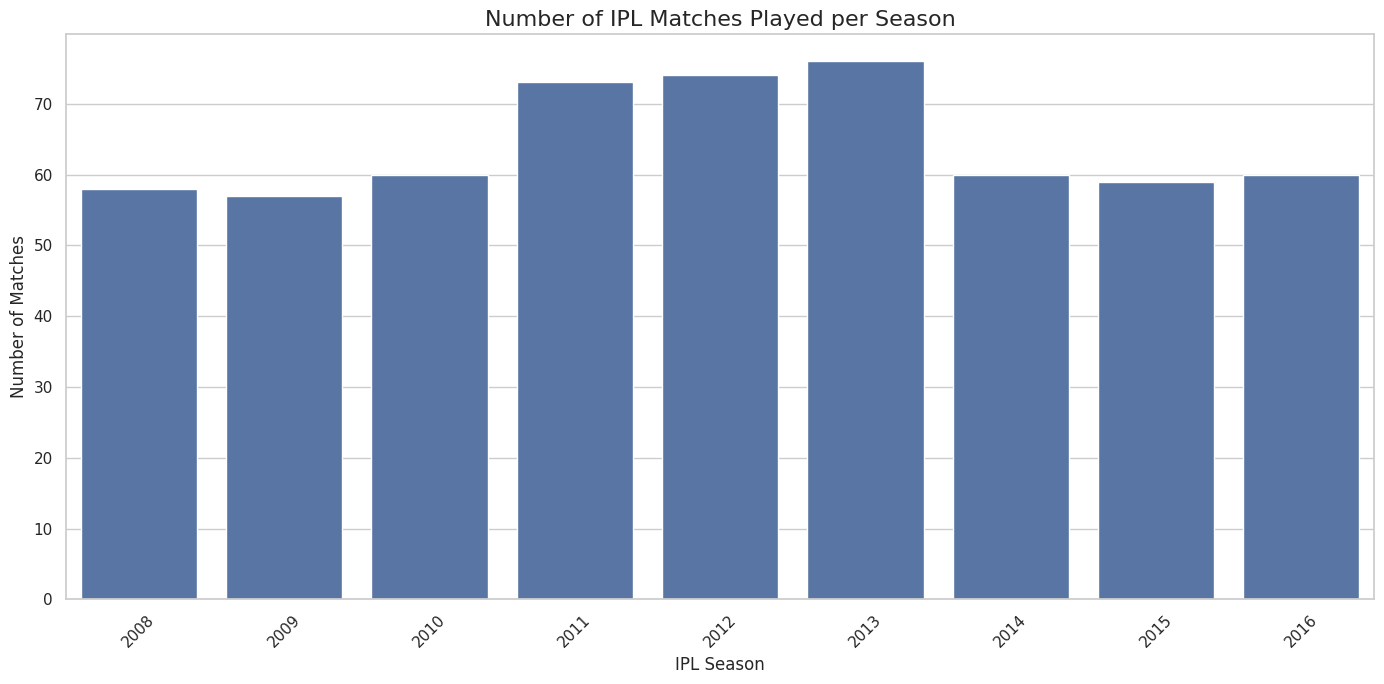

In [16]:
season_matches = (
    df.groupby("season")
      .size()
      .reset_index(name="matches")
)

plt.figure(figsize=(14, 7))

sns.barplot(
    data=season_matches,
    x="season",
    y="matches"
)

plt.title("Number of IPL Matches Played per Season")
plt.xlabel("IPL Season")
plt.ylabel("Number of Matches")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

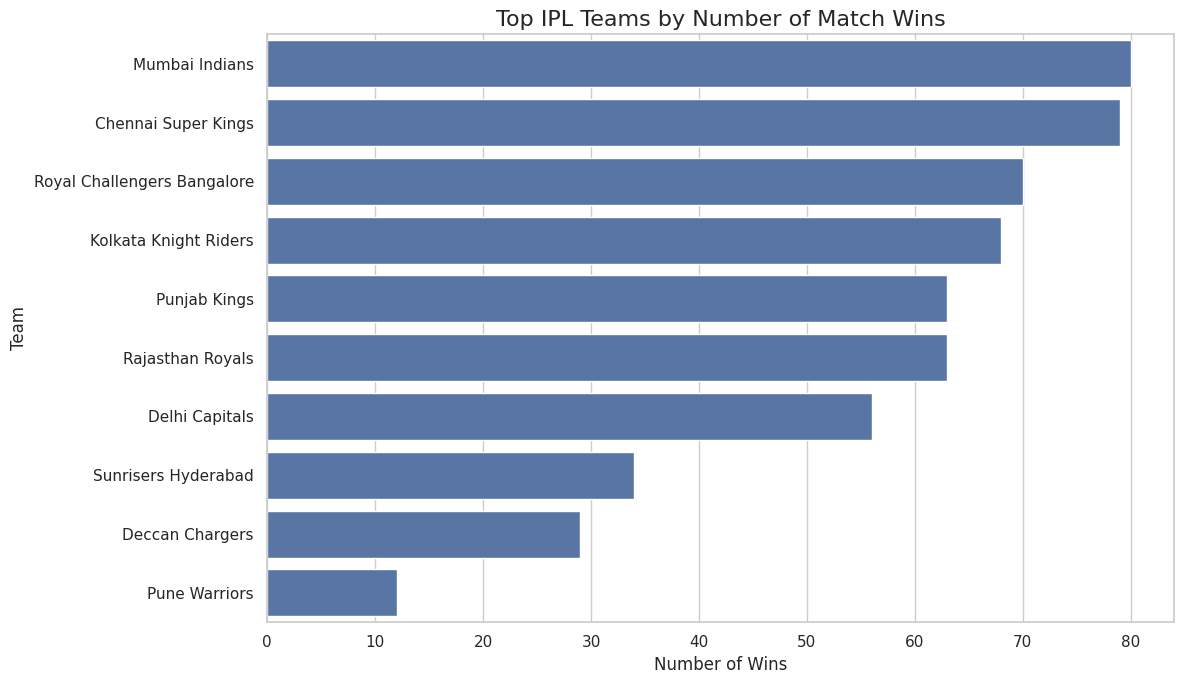

In [17]:
team_wins = (
    df["winner"]
    .value_counts()
    .head(10)
    .reset_index()
)

team_wins.columns = ["team", "wins"]

plt.figure(figsize=(12, 7))

sns.barplot(
    data=team_wins,
    y="team",
    x="wins"
)

plt.title("Top IPL Teams by Number of Match Wins")
plt.xlabel("Number of Wins")
plt.ylabel("Team")

plt.tight_layout()
plt.show()

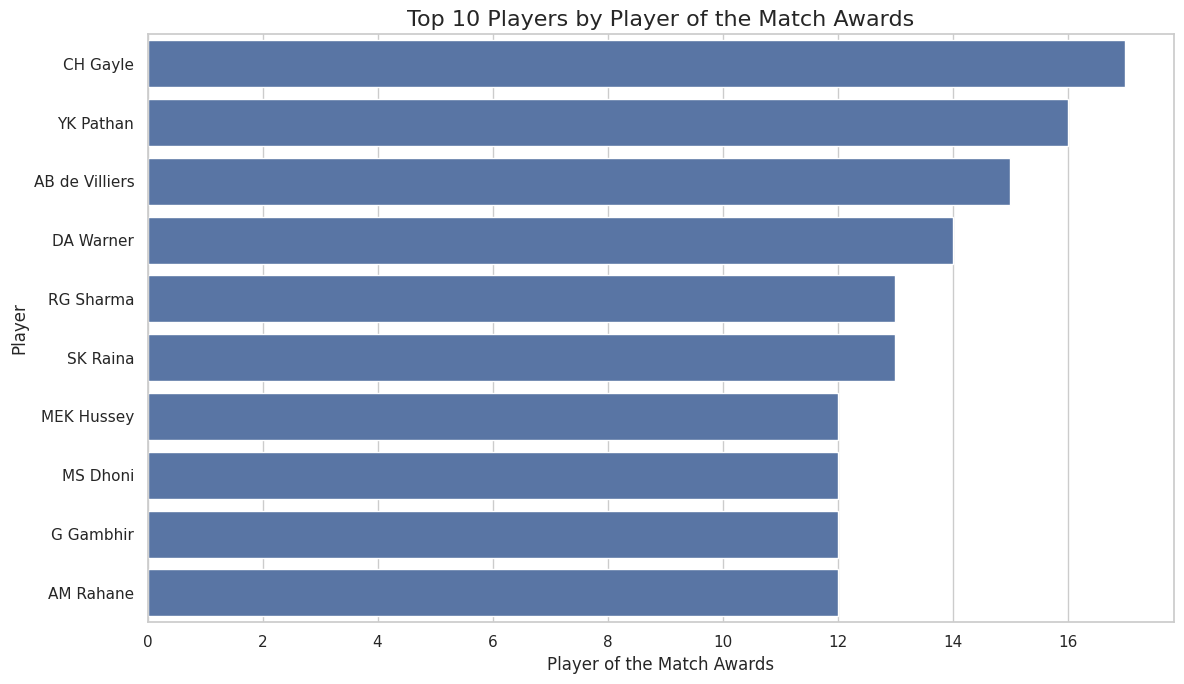

In [18]:
top_players = (
    df[df["player_of_match"] != "Unknown"]
    ["player_of_match"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_players.columns = [
    "player",
    "awards"
]

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_players,
    y="player",
    x="awards"
)

plt.title("Top 10 Players by Player of the Match Awards")
plt.xlabel("Player of the Match Awards")
plt.ylabel("Player")

plt.tight_layout()
plt.show()

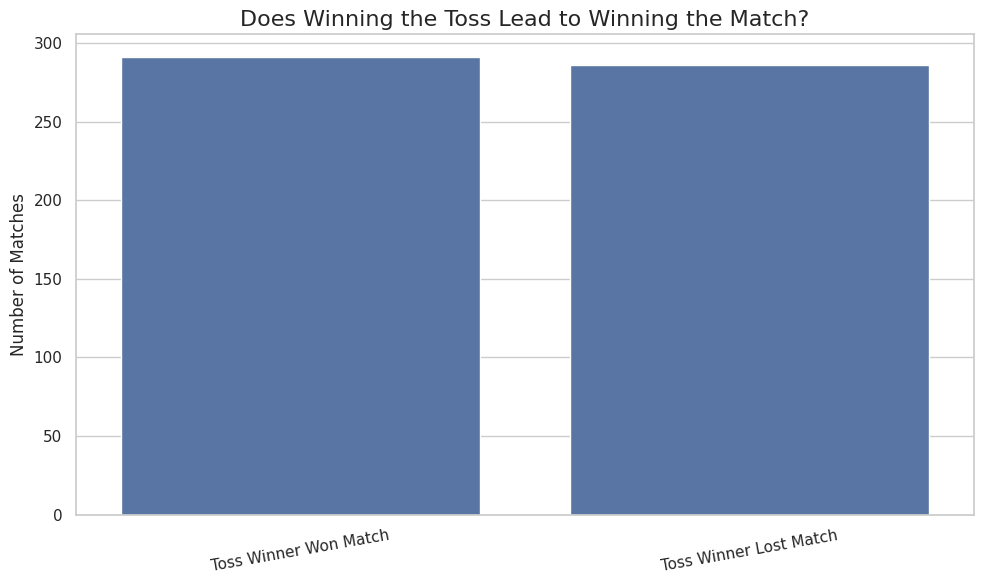

In [20]:
df["toss_match_winner"] = (
    df["toss_winner"] == df["winner"]
)

toss_result = (
    df["toss_match_winner"]
    .value_counts()
    .reset_index()
)

toss_result.columns = [
    "result",
    "matches"
]

toss_result["result"] = toss_result["result"].map({
    True: "Toss Winner Won Match",
    False: "Toss Winner Lost Match"
})

plt.figure(figsize=(10, 6))

sns.barplot(
    data=toss_result,
    x="result",
    y="matches"
)

plt.title("Does Winning the Toss Lead to Winning the Match?")
plt.xlabel("")
plt.ylabel("Number of Matches")

plt.xticks(rotation=10)

plt.tight_layout()
plt.show()

In [21]:
toss_win_percentage = (
    df["toss_match_winner"].mean() * 100
)

print(
    f"Toss winner also won the match in "
    f"{toss_win_percentage:.2f}% of matches."
)

Toss winner also won the match in 50.43% of matches.


In [22]:
print(f"""
BUSINESS / SPORTS INSIGHT:

The toss winner also won approximately
{toss_win_percentage:.2f}% of the matches in the dataset.

This indicates whether winning the toss appears to provide a
meaningful advantage, although it does not guarantee victory.
""")


BUSINESS / SPORTS INSIGHT:

The toss winner also won approximately
50.43% of the matches in the dataset.

This indicates whether winning the toss appears to provide a
meaningful advantage, although it does not guarantee victory.



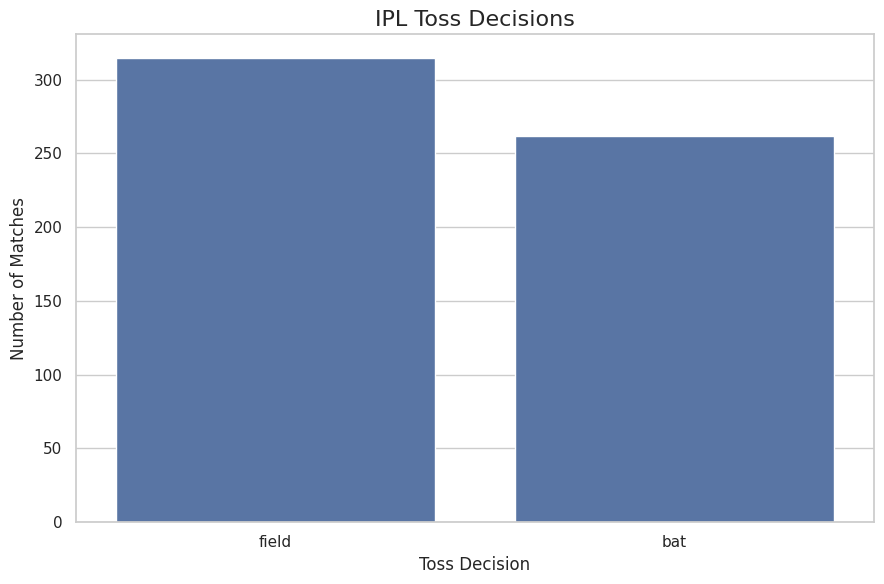

In [23]:
toss_decision = (
    df["toss_decision"]
    .value_counts()
    .reset_index()
)

toss_decision.columns = [
    "decision",
    "matches"
]

plt.figure(figsize=(9, 6))

sns.barplot(
    data=toss_decision,
    x="decision",
    y="matches"
)

plt.title("IPL Toss Decisions")
plt.xlabel("Toss Decision")
plt.ylabel("Number of Matches")

plt.tight_layout()
plt.show()

In [24]:
print("""
BUSINESS / SPORTS INSIGHT:

The chart shows whether captains generally preferred batting first
or fielding first after winning the toss. Changes in this preference
can reflect changing strategies and playing conditions.
""")


BUSINESS / SPORTS INSIGHT:

The chart shows whether captains generally preferred batting first
or fielding first after winning the toss. Changes in this preference
can reflect changing strategies and playing conditions.



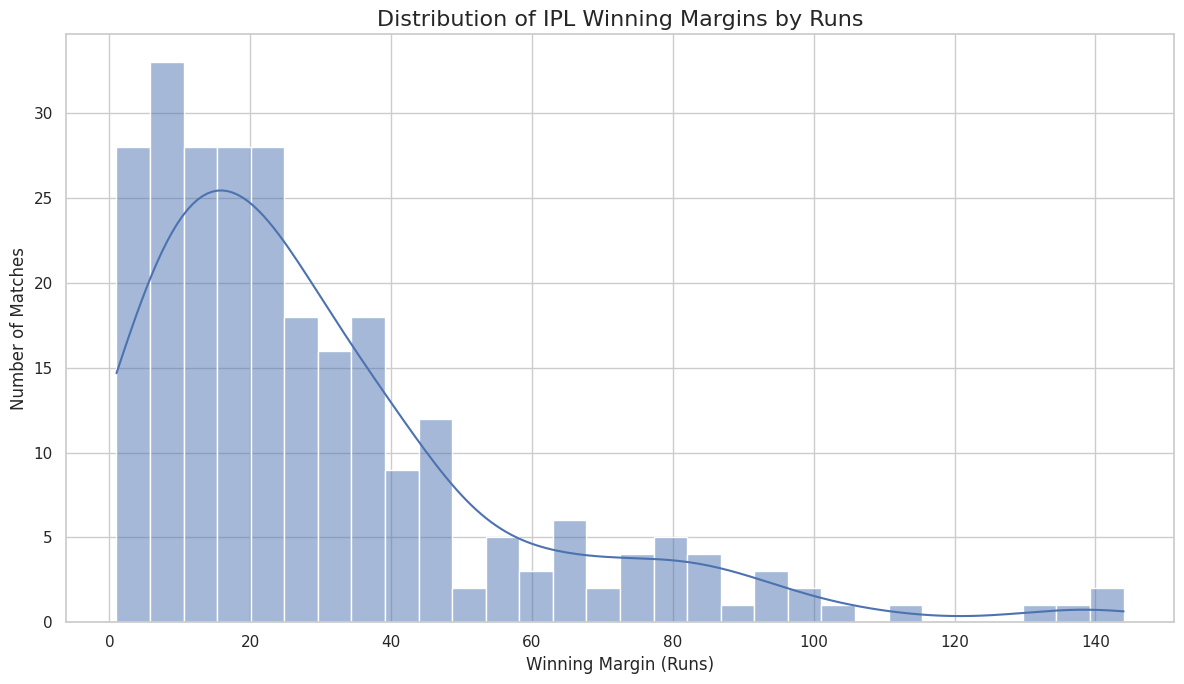

In [25]:
run_wins = df[df["win_by_runs"] > 0]["win_by_runs"]

plt.figure(figsize=(12, 7))

sns.histplot(
    run_wins,
    bins=30,
    kde=True
)

plt.title("Distribution of IPL Winning Margins by Runs")
plt.xlabel("Winning Margin (Runs)")
plt.ylabel("Number of Matches")

plt.tight_layout()
plt.show()

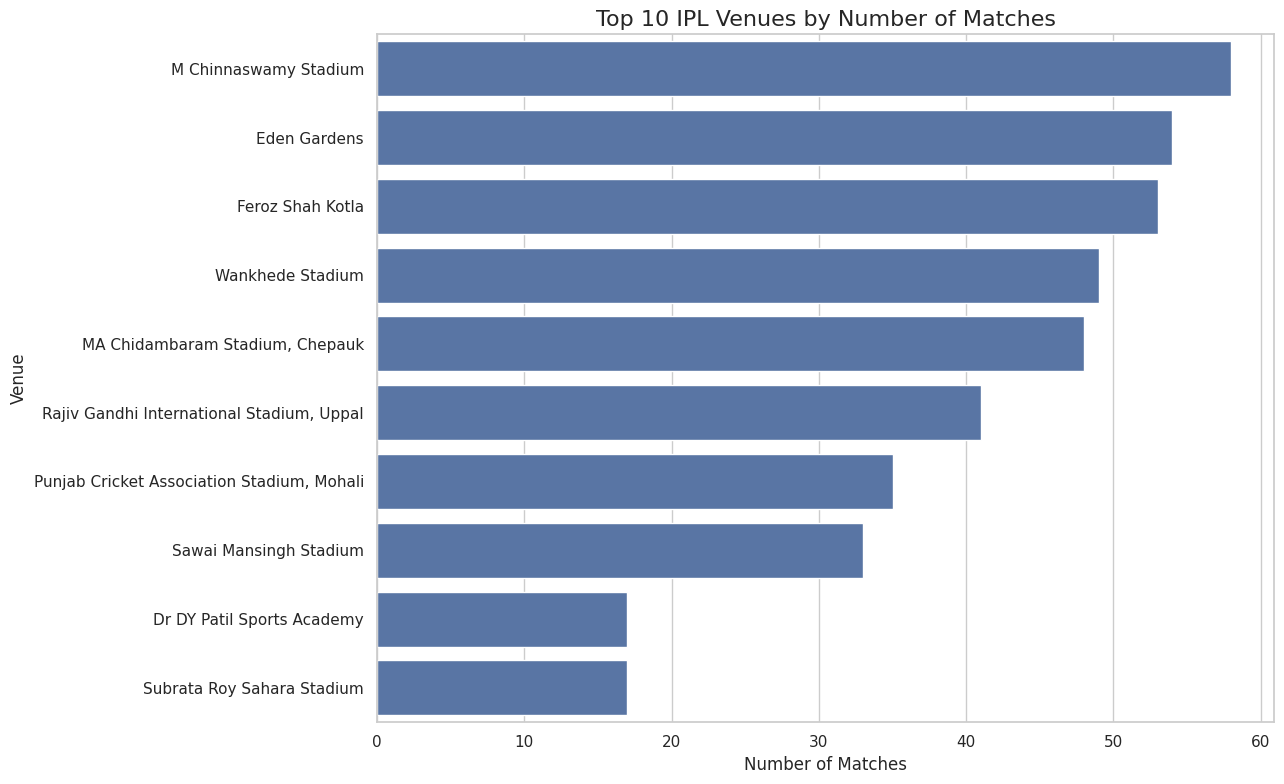

In [26]:
venue_matches = (
    df["venue"]
    .value_counts()
    .head(10)
    .reset_index()
)

venue_matches.columns = [
    "venue",
    "matches"
]

plt.figure(figsize=(13, 8))

sns.barplot(
    data=venue_matches,
    y="venue",
    x="matches"
)

plt.title("Top 10 IPL Venues by Number of Matches")
plt.xlabel("Number of Matches")
plt.ylabel("Venue")

plt.tight_layout()
plt.show()

In [27]:
teams = sorted(
    set(df["team1"].dropna()) |
    set(df["team2"].dropna())
)

team_statistics = []

for team in teams:

    matches_played = (
        (df["team1"] == team) |
        (df["team2"] == team)
    ).sum()

    matches_won = (
        df["winner"] == team
    ).sum()

    win_percentage = (
        matches_won / matches_played * 100
        if matches_played > 0
        else 0
    )

    team_statistics.append({
        "Team": team,
        "Matches Played": matches_played,
        "Wins": matches_won,
        "Win Percentage": win_percentage
    })

team_stats = pd.DataFrame(team_statistics)

team_stats = (
    team_stats
    .sort_values("Win Percentage", ascending=False)
)

display(team_stats.head(10))

,Team,Matches Played,Wins,Win Percentage
0,Chennai Super Kings,131,79,60.305344
6,Mumbai Indians,140,80,57.142857
3,Gujarat Lions,16,9,56.250000
12,Sunrisers Hyderabad,62,34,54.838710
9,Rajasthan Royals,118,63,53.389831
5,Kolkata Knight Riders,132,68,51.515152
11,Royal Challengers Bangalore,139,70,50.359712
8,Punjab Kings,134,63,47.014925
4,Kochi Tuskers Kerala,14,6,42.857143
2,Delhi Capitals,133,56,42.105263


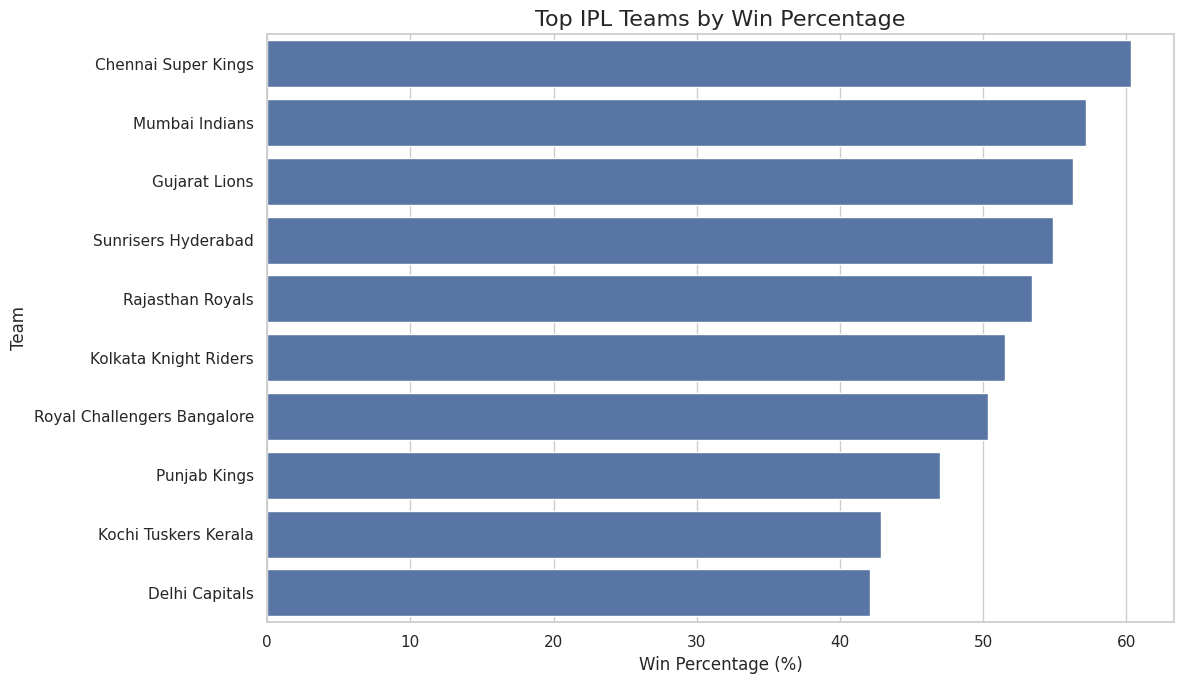

In [28]:
top_team_stats = team_stats.head(10)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_team_stats,
    x="Win Percentage",
    y="Team"
)

plt.title("Top IPL Teams by Win Percentage")
plt.xlabel("Win Percentage (%)")
plt.ylabel("Team")

plt.tight_layout()
plt.show()

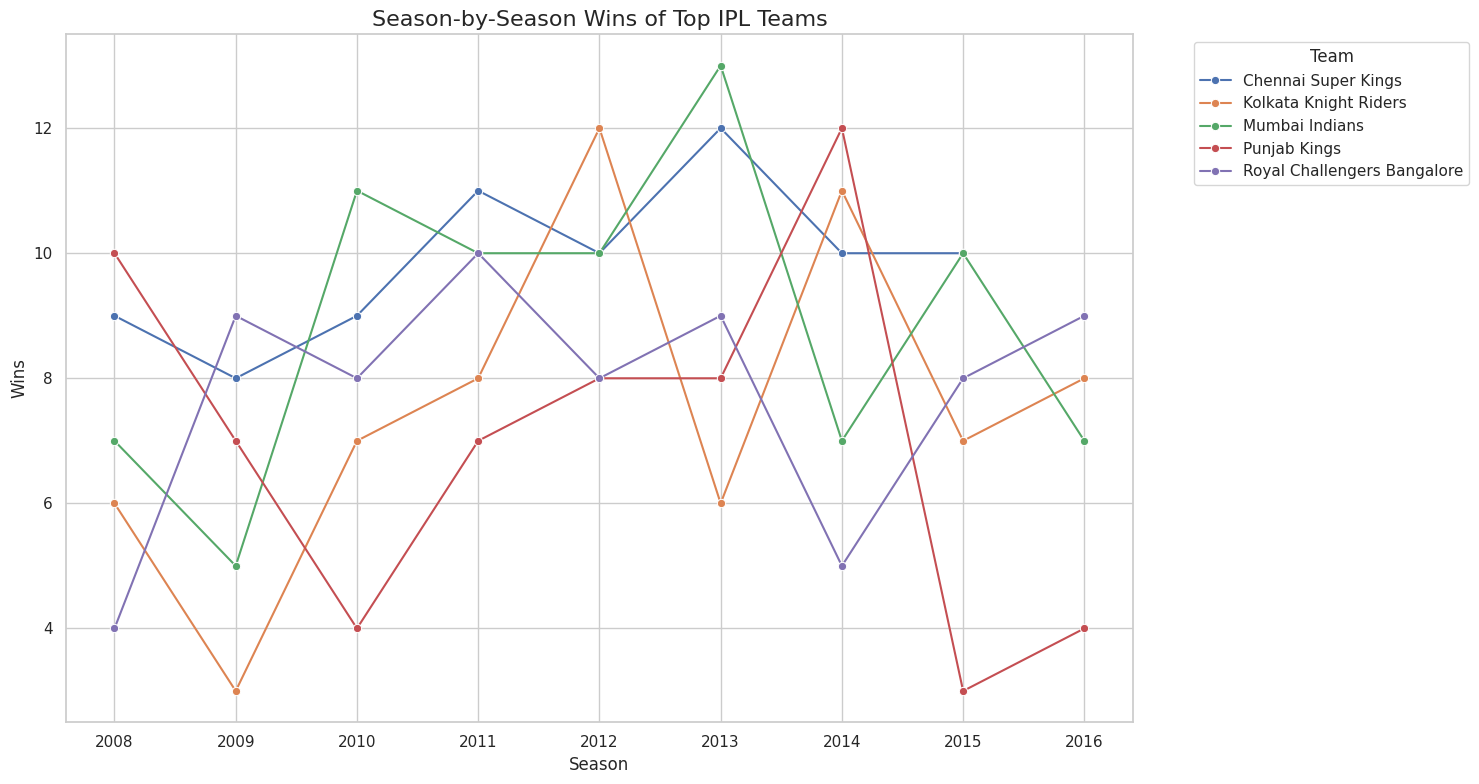

In [29]:
season_wins = (
    df.groupby(["season", "winner"])
      .size()
      .reset_index(name="wins")
)

top_teams = (
    df["winner"]
    .value_counts()
    .head(5)
    .index
)

trend_data = season_wins[
    season_wins["winner"].isin(top_teams)
]

plt.figure(figsize=(15, 8))

sns.lineplot(
    data=trend_data,
    x="season",
    y="wins",
    hue="winner",
    marker="o"
)

plt.title("Season-by-Season Wins of Top IPL Teams")
plt.xlabel("Season")
plt.ylabel("Wins")

plt.legend(
    title="Team",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [30]:
total_matches = len(df)

total_seasons = df["season"].nunique()

total_teams = len(
    set(df["team1"].dropna()) |
    set(df["team2"].dropna())
)

top_team = df["winner"].value_counts().idxmax()
top_team_wins = df["winner"].value_counts().max()

top_player = (
    df[df["player_of_match"] != "Unknown"]
    ["player_of_match"]
    .value_counts()
    .idxmax()
)

top_player_awards = (
    df[df["player_of_match"] != "Unknown"]
    ["player_of_match"]
    .value_counts()
    .max()
)

print("TOTAL MATCHES:", total_matches)
print("TOTAL SEASONS:", total_seasons)
print("TOTAL TEAMS:", total_teams)
print("MOST SUCCESSFUL TEAM:", top_team)
print("TEAM WINS:", top_team_wins)
print("TOP PLAYER:", top_player)
print("PLAYER OF MATCH AWARDS:", top_player_awards)

TOTAL MATCHES: 577
TOTAL SEASONS: 9
TOTAL TEAMS: 13
MOST SUCCESSFUL TEAM: Mumbai Indians
TEAM WINS: 80
TOP PLAYER: CH Gayle
PLAYER OF MATCH AWARDS: 17


In [31]:
# ============================================================
# INTERACTIVE DASHBOARD
# ============================================================

dashboard_html = """
<h1 style="text-align:center;">
🏏 IPL SPORTS DATASET VISUAL STORY
</h1>

<h3 style="text-align:center;">
Interactive Performance Dashboard
</h3>
"""

display(HTML(dashboard_html))

In [32]:
fig1 = px.bar(
    season_matches,
    x="season",
    y="matches",
    title="Matches Played by IPL Season",
    labels={
        "season": "Season",
        "matches": "Matches"
    }
)

fig1.show()

In [33]:
fig2 = px.bar(
    team_wins,
    x="wins",
    y="team",
    orientation="h",
    title="Top IPL Teams by Wins",
    labels={
        "wins": "Wins",
        "team": "Team"
    }
)

fig2.show()

In [34]:
fig3 = px.bar(
    top_players,
    x="awards",
    y="player",
    orientation="h",
    title="Top Players by Player of the Match Awards",
    labels={
        "awards": "Awards",
        "player": "Player"
    }
)

fig3.show()

In [35]:
fig4 = px.pie(
    toss_result,
    names="result",
    values="matches",
    title="Toss Winner vs Match Winner"
)

fig4.show()

In [36]:
fig5 = px.bar(
    venue_matches,
    x="matches",
    y="venue",
    orientation="h",
    title="Top IPL Venues",
    labels={
        "matches": "Matches",
        "venue": "Venue"
    }
)

fig5.show()

In [37]:
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[
        "Matches per Season",
        "Top Teams by Wins",
        "Top Players",
        "Toss vs Match Winner"
    ],
    specs=[
        [{"type": "bar"}, {"type": "bar"}],
        [{"type": "bar"}, {"type": "pie"}]
    ]
)

# Chart 1
fig.add_trace(
    go.Bar(
        x=season_matches["season"],
        y=season_matches["matches"],
        name="Matches"
    ),
    row=1,
    col=1
)

# Chart 2
fig.add_trace(
    go.Bar(
        x=team_wins["wins"],
        y=team_wins["team"],
        orientation="h",
        name="Wins"
    ),
    row=1,
    col=2
)

# Chart 3
fig.add_trace(
    go.Bar(
        x=top_players["awards"],
        y=top_players["player"],
        orientation="h",
        name="Awards"
    ),
    row=2,
    col=1
)

# Chart 4
fig.add_trace(
    go.Pie(
        labels=toss_result["result"],
        values=toss_result["matches"],
        name="Toss"
    ),
    row=2,
    col=2
)

fig.update_layout(
    title="IPL Sports Dataset Visual Story Dashboard",
    height=1000,
    showlegend=False
)

fig.show()

In [38]:
dashboard_path = "/content/IPL_Visual_Story_Dashboard.html"

fig.write_html(dashboard_path)

print("Dashboard saved:")
print(dashboard_path)

Dashboard saved:
/content/IPL_Visual_Story_Dashboard.html


In [39]:
import os

report_dir = Path("/content/ipl_report")
report_dir.mkdir(exist_ok=True)

print("Report directory created:", report_dir)

Report directory created: /content/ipl_report


In [40]:
# Chart 1
plt.figure(figsize=(12, 6))
sns.barplot(
    data=season_matches,
    x="season",
    y="matches"
)
plt.title("Number of IPL Matches Played per Season")
plt.xticks(rotation=45)
plt.tight_layout()

chart1_path = report_dir / "matches_per_season.png"
plt.savefig(chart1_path, dpi=200)
plt.close()


# Chart 2
plt.figure(figsize=(12, 6))
sns.barplot(
    data=team_wins,
    y="team",
    x="wins"
)
plt.title("Top IPL Teams by Number of Wins")
plt.tight_layout()

chart2_path = report_dir / "team_wins.png"
plt.savefig(chart2_path, dpi=200)
plt.close()


# Chart 3
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_players,
    y="player",
    x="awards"
)
plt.title("Top Players by Player of the Match Awards")
plt.tight_layout()

chart3_path = report_dir / "top_players.png"
plt.savefig(chart3_path, dpi=200)
plt.close()


# Chart 4
plt.figure(figsize=(10, 6))
sns.barplot(
    data=toss_result,
    x="result",
    y="matches"
)
plt.title("Toss Winner vs Match Winner")
plt.xticks(rotation=10)
plt.tight_layout()

chart4_path = report_dir / "toss_analysis.png"
plt.savefig(chart4_path, dpi=200)
plt.close()


# Chart 5
plt.figure(figsize=(12, 7))
sns.barplot(
    data=venue_matches,
    y="venue",
    x="matches"
)
plt.title("Top IPL Venues")
plt.tight_layout()

chart5_path = report_dir / "top_venues.png"
plt.savefig(chart5_path, dpi=200)
plt.close()

In [41]:
from reportlab.lib.pagesizes import A4
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Image,
    PageBreak
)

from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.enums import TA_CENTER

from reportlab.lib.units import inch


pdf_path = "/content/IPL_Sports_Dataset_Visual_Story_Report.pdf"

styles = getSampleStyleSheet()

title_style = styles["Title"]
heading_style = styles["Heading2"]
body_style = styles["BodyText"]

title_style.alignment = TA_CENTER

doc = SimpleDocTemplate(
    pdf_path,
    pagesize=A4,
    rightMargin=40,
    leftMargin=40,
    topMargin=40,
    bottomMargin=40
)

story = []

# ------------------------------------------------------------
# TITLE
# ------------------------------------------------------------

story.append(
    Paragraph(
        "Sports Dataset Visual Story",
        title_style
    )
)

story.append(
    Paragraph(
        "IPL Performance Analysis Using Python",
        heading_style
    )
)

story.append(Spacer(1, 20))

story.append(
    Paragraph(
        f"""
        This project analyses IPL match data using Python, Pandas,
        Matplotlib and Seaborn. The objective is to clean the data,
        identify performance trends and communicate important findings
        through data visualization.
        """,
        body_style
    )
)

story.append(Spacer(1, 20))

# ------------------------------------------------------------
# DATASET SUMMARY
# ------------------------------------------------------------

story.append(
    Paragraph(
        "1. Dataset Summary",
        heading_style
    )
)

summary_text = f"""
Total Matches: {total_matches}<br/>
Total Seasons: {total_seasons}<br/>
Number of Teams: {total_teams}<br/>
Most Successful Team by Wins: {top_team}<br/>
Top Player by Player of the Match Awards: {top_player}
"""

story.append(
    Paragraph(
        summary_text,
        body_style
    )
)

story.append(PageBreak())

# ------------------------------------------------------------
# CHART 1
# ------------------------------------------------------------

story.append(
    Paragraph(
        "2. Matches Played per Season",
        heading_style
    )
)

story.append(
    Image(
        str(chart1_path),
        width=6.5 * inch,
        height=3.8 * inch
    )
)

story.append(
    Paragraph(
        """
        Insight: The number of matches differs between seasons because
        tournament structures, participating teams and scheduling have
        changed over time.
        """,
        body_style
    )
)

story.append(PageBreak())

# ------------------------------------------------------------
# CHART 2
# ------------------------------------------------------------

story.append(
    Paragraph(
        "3. Team Performance",
        heading_style
    )
)

story.append(
    Image(
        str(chart2_path),
        width=6.5 * inch,
        height=3.8 * inch
    )
)

story.append(
    Paragraph(
        """
        Insight: The teams at the top have accumulated the highest
        number of victories, indicating strong long-term performance.
        """,
        body_style
    )
)

story.append(PageBreak())

# ------------------------------------------------------------
# CHART 3
# ------------------------------------------------------------

story.append(
    Paragraph(
        "4. Player Performance",
        heading_style
    )
)

story.append(
    Image(
        str(chart3_path),
        width=6.5 * inch,
        height=3.8 * inch
    )
)

story.append(
    Paragraph(
        """
        Insight: Players with many Player of the Match awards have
        repeatedly produced influential match-winning performances.
        """,
        body_style
    )
)

story.append(PageBreak())

# ------------------------------------------------------------
# CHART 4
# ------------------------------------------------------------

story.append(
    Paragraph(
        "5. Toss Analysis",
        heading_style
    )
)

story.append(
    Image(
        str(chart4_path),
        width=6.5 * inch,
        height=3.8 * inch
    )
)

story.append(
    Paragraph(
        f"""
        Insight: The toss winner also won approximately
        {toss_win_percentage:.2f}% of the matches in the dataset.
        Winning the toss therefore provides an opportunity but does
        not guarantee match victory.
        """,
        body_style
    )
)

story.append(PageBreak())

# ------------------------------------------------------------
# CHART 5
# ------------------------------------------------------------

story.append(
    Paragraph(
        "6. Venue Analysis",
        heading_style
    )
)

story.append(
    Image(
        str(chart5_path),
        width=6.5 * inch,
        height=3.8 * inch
    )
)

story.append(
    Paragraph(
        """
        Insight: A relatively small group of major cricket venues
        account for a large share of IPL matches.
        """,
        body_style
    )
)

story.append(PageBreak())

# ------------------------------------------------------------
# CONCLUSION
# ------------------------------------------------------------

story.append(
    Paragraph(
        "7. Conclusion",
        heading_style
    )
)

story.append(
    Paragraph(
        """
        The IPL dataset provides useful evidence about team success,
        player impact, toss decisions, venues and season-level trends.
        Data cleaning and visualization make these patterns easier to
        understand and communicate. The project demonstrates how
        Python-based data analysis can convert raw sports data into
        meaningful visual insights.
        """,
        body_style
    )
)

doc.build(story)

print("PDF generated successfully!")
print(pdf_path)

PDF generated successfully!
/content/IPL_Sports_Dataset_Visual_Story_Report.pdf


In [42]:
from google.colab import files

files.download(
    "/content/IPL_Sports_Dataset_Visual_Story_Report.pdf"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [43]:
files.download(
    "/content/IPL_Visual_Story_Dashboard.html"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [44]:
from google.colab import files
import os
import zipfile

# Folder containing your chart images
chart_dir = "/content/ipl_report"

# Create a ZIP file containing all chart images
zip_path = "/content/IPL_Charts.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for filename in os.listdir(chart_dir):
        if filename.endswith((".png", ".jpg", ".jpeg")):
            filepath = os.path.join(chart_dir, filename)
            zipf.write(filepath, arcname=filename)

print("Charts successfully compressed.")
print("Downloading ZIP file...")

files.download(zip_path)

Charts successfully compressed.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>